# Znajdywanie kolorów chwytaka

## Tworzenie dataframe

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
# Dodanie dźwięku przy długich komórkach
import subprocess
def play_sound():
    sound_file = '/mnt/d/Backup/INZ/msg.ogg'
    subprocess.run(['ffplay', '-nodisp', '-autoexit', sound_file], capture_output=True)

In [3]:
SAVE_DIR = Path("/mnt/d/Backup/MAGISTERSKIE/outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# masks_array = np.load(f'{SAVE_DIR}/masks_array.npy')
# incomplete_detect = np.load(f'{SAVE_DIR}/incomplete_detect.npy')
df = pd.read_csv(f'{SAVE_DIR}/df.csv')
color_paths_for_llms = df.loc[20:119,"color_path"]
color_paths_for_llms.head()

20    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
21    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
22    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
23    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
24    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
Name: color_path, dtype: object

#### DLA OPENAI

In [6]:
import base64
from openai import OpenAI
import os

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

Kodowanie base64 do API openai

In [7]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")
    
encoded_images_gpt = color_paths_for_llms.apply(encode_image).to_numpy().reshape(-1,1)

# encoded_images_gpt = np.delete(encoded_images_gpt, incomplete_detect, axis=0)
# play_sound()

print(encoded_images_gpt.shape)
# encoded_images_gpt[:5]

(100, 1)


In [ ]:
import re
from pathlib import Path

def normalize_bbox_output(text):
    text = str(text).strip().replace("\n", "")
    boxes = re.findall(
        r'\(([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\)',
        text
    )
    if len(boxes) != 3:
        return None

    parsed = []
    for box in boxes:
        x_min, y_min, x_max, y_max = [float(v) for v in box]
        if not (0.0 <= x_min <= 1.0 and 0.0 <= y_min <= 1.0 and 0.0 <= x_max <= 1.0 and 0.0 <= y_max <= 1.0):
            return None
        if x_min >= x_max or y_min >= y_max:
            return None
        parsed.append((x_min, y_min, x_max, y_max))

    return ",".join([
        f"({x_min:.6f},{y_min:.6f},{x_max:.6f},{y_max:.6f})"
        for x_min, y_min, x_max, y_max in parsed
    ])

def parse_bbox_string(text):
    normalized = normalize_bbox_output(text)
    if normalized is None:
        return None
    boxes = re.findall(
        r'\(([0-9]*\.?[0-9]+),([0-9]*\.?[0-9]+),([0-9]*\.?[0-9]+),([0-9]*\.?[0-9]+)\)',
        normalized
    )
    return [[float(v) for v in box] for box in boxes]

def median_consensus_bbox(candidates):
    valid = [c for c in candidates if c is not None and len(c) == 3]
    if len(valid) < 2:
        return None
    arr = np.array(valid, dtype=float)
    med = np.median(arr, axis=0)
    out = []
    for box in med:
        x_min, y_min, x_max, y_max = [float(v) for v in box]
        x_min = min(max(x_min, 0.0), 1.0)
        y_min = min(max(y_min, 0.0), 1.0)
        x_max = min(max(x_max, 0.0), 1.0)
        y_max = min(max(y_max, 0.0), 1.0)
        if x_min >= x_max or y_min >= y_max:
            return None
        out.append((x_min, y_min, x_max, y_max))
    return ",".join([
        f"({x_min:.6f},{y_min:.6f},{x_max:.6f},{y_max:.6f})"
        for x_min, y_min, x_max, y_max in out
    ])

openai_invalid_rows = []
openai_retry_success = 0
openai_retry_failed = 0
openai_consensus_used = 0

base_prompt = (
    "Detect exactly 3 objects on the robot gripper in this exact order: "
    "1) pink robot finger gripper on the robot gripper, "
    "2) green small rectangle on the robot gripper, "
    "3) blue robot finger gripper on the robot gripper. "
    "Return exactly one line in this exact format: "
    "(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max). "
    "Rules: values must be decimal numbers in [0,1], with x_min<x_max and y_min<y_max. "
    "The green box should usually be smaller than pink and blue. "
    "Return only coordinates, no extra text."
)

checkpoint_path = Path(SAVE_DIR) / "LLM" / "xy_array_gpt.npy"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

if checkpoint_path.exists():
    loaded = np.load(checkpoint_path, allow_pickle=True)
    xy_array_gpt = loaded.tolist() if isinstance(loaded, np.ndarray) else list(loaded)
    start_idx = len(xy_array_gpt)
    print(f"Resume from index {start_idx} (loaded from {checkpoint_path})")
else:
    xy_array_gpt = []
    start_idx = 0
    print("No previous file found. Starting from index 0.")

total_images = encoded_images_gpt.shape[0]
if start_idx > total_images:
    raise ValueError(f"Saved results ({start_idx}) exceed available images ({total_images}).")

for i in range(start_idx, total_images):
    base64_image = encoded_images_gpt[i][0]

    sampled = []
    for _ in range(3):
        response = client.responses.create(
            model="gpt-5",
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": base_prompt},
                        {
                            "type": "input_image",
                            "image_url": f"data:image/jpeg;base64,{base64_image}",
                            "detail": "high"
                        },
                    ],
                }
            ],
        )
        sampled.append(parse_bbox_string(response.output_text.strip()))

    consensus = median_consensus_bbox(sampled)
    retried = False

    if consensus is None:
        retried = True
        retry_prompt = f"{base_prompt} Follow the output format exactly."
        retry_response = client.responses.create(
            model="gpt-5",
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": retry_prompt},
                        {
                            "type": "input_image",
                            "image_url": f"data:image/jpeg;base64,{base64_image}",
                            "detail": "high"
                        },
                    ],
                }
            ],
        )
        consensus = normalize_bbox_output(retry_response.output_text.strip())

    if consensus is None:
        openai_invalid_rows.append(i)
        if retried:
            openai_retry_failed += 1
        xy_array_gpt.append("")
    else:
        if any(s is not None for s in sampled):
            openai_consensus_used += 1
        if retried:
            openai_retry_success += 1
        xy_array_gpt.append(consensus)

    if ((i + 1) % 5 == 0) or (i == total_images - 1):
        np.save(checkpoint_path, np.array(xy_array_gpt, dtype=object))
        print(f"Checkpoint saved: {i + 1}/{total_images}")

print(f"OpenAI invalid rows (this run): {len(openai_invalid_rows)}")
print(f"OpenAI consensus used (this run): {openai_consensus_used}")
print(f"OpenAI retry fixed: {openai_retry_success}, still invalid after retry: {openai_retry_failed}")
print(f"Total saved rows: {len(xy_array_gpt)}/{total_images}")
if openai_invalid_rows:
    print(f"First invalid indices: {openai_invalid_rows[:10]}")

np.save(checkpoint_path, np.array(xy_array_gpt, dtype=object))
play_sound()

Resume from index 10 (loaded from /mnt/d/Backup/MAGISTERSKIE/outputs/LLM/xy_array_gpt.npy)
Checkpoint saved: 15/100
Checkpoint saved: 20/100
Checkpoint saved: 25/100
Checkpoint saved: 30/100
Checkpoint saved: 35/100
Checkpoint saved: 40/100
Checkpoint saved: 45/100
Checkpoint saved: 50/100
Checkpoint saved: 55/100
Checkpoint saved: 60/100
Checkpoint saved: 65/100
Checkpoint saved: 70/100
Checkpoint saved: 75/100
Checkpoint saved: 80/100
Checkpoint saved: 85/100
Checkpoint saved: 90/100
Checkpoint saved: 95/100
Checkpoint saved: 100/100
OpenAI invalid rows (this run): 0
OpenAI consensus used (this run): 90
OpenAI retry fixed: 0, still invalid after retry: 0
Total saved rows: 100/100


In [16]:
xy_array_gpt

array(['(0.400000,0.380000,0.460000,0.600000),(0.354000,0.300000,0.392000,0.380000),(0.470000,0.420000,0.540000,0.620000)',
       '(0.368000,0.476000,0.427000,0.581000),(0.397000,0.360000,0.430000,0.435000),(0.445000,0.420000,0.504000,0.600000)',
       '(0.285000,0.440000,0.355000,0.575000),(0.355000,0.430000,0.395000,0.485000),(0.395000,0.400000,0.470000,0.520000)',
       '(0.400000,0.340000,0.520000,0.570000),(0.470000,0.250000,0.540000,0.330000),(0.540000,0.350000,0.630000,0.600000)',
       '(0.260000,0.400000,0.360000,0.550000),(0.320000,0.270000,0.370000,0.360000),(0.350000,0.500000,0.450000,0.660000)',
       '(0.330000,0.470000,0.410000,0.620000),(0.420000,0.430000,0.460000,0.490000),(0.410000,0.580000,0.490000,0.720000)',
       '(0.430000,0.330000,0.490000,0.470000),(0.490000,0.300000,0.560000,0.370000),(0.540000,0.340000,0.600000,0.570000)',
       '(0.365000,0.370000,0.450000,0.490000),(0.455000,0.380000,0.490000,0.460000),(0.400000,0.500000,0.490000,0.640000)',
       '

In [ ]:
# np.save(f'{SAVE_DIR}/LLM/xy_array_gpt100.npy', xy_array_gpt)

#### DLA GOOGLE

In [12]:
import dotenv
dotenv.load_dotenv()

True

In [13]:
import google.generativeai as genai
import os

genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

models = [m.name for m in genai.list_models()
          if "generateContent" in getattr(m, "supported_generation_methods", [])]
print([m for m in models if "robot" in m.lower() or "er" in m.lower() or "1.5" in m.lower()])

# Zmieniono na gemini-2.0-flash - wyższe limity, brak rate limitingu
model = genai.GenerativeModel('models/gemini-2.0-flash')

/home/ruszczka/projekty/test_files/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


['models/gemini-robotics-er-1.5-preview', 'models/gemini-2.5-computer-use-preview-10-2025']


In [14]:
encoded_images_gemini = color_paths_for_llms.to_numpy().reshape(-1,1)

# encoded_images_gemini = np.delete(encoded_images_gemini, incomplete_detect, axis=0)
encoded_images_gemini.shape

(200, 1)

##### KONWERSJA

In [15]:
import time
import traceback
import re

def normalize_bbox_output(text):
    text = str(text).strip().replace("\n", "")
    boxes = re.findall(
        r'\(([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\)',
        text
    )
    if len(boxes) != 3:
        return None

    parsed = []
    for box in boxes:
        x_min, y_min, x_max, y_max = [float(v) for v in box]
        if not (0.0 <= x_min <= 1.0 and 0.0 <= y_min <= 1.0 and 0.0 <= x_max <= 1.0 and 0.0 <= y_max <= 1.0):
            return None
        if x_min >= x_max or y_min >= y_max:
            return None
        parsed.append((x_min, y_min, x_max, y_max))

    return ",".join([
        f"({x_min:.6f},{y_min:.6f},{x_max:.6f},{y_max:.6f})"
        for x_min, y_min, x_max, y_max in parsed
    ])

xy_array_gemini = []
errors = []
gemini_invalid_rows = []
gemini_retry_success = 0
gemini_retry_failed = 0
checkpoint_file = f'{SAVE_DIR}/LLM/xy_array_gemini_checkpoint.npy'

# Spróbuj wczytać istniejący checkpoint
try:
    xy_array_gemini = np.load(checkpoint_file, allow_pickle=True).tolist()
    start_idx = len(xy_array_gemini)
    print(f"Wznowienie od obrazu {start_idx}")
except FileNotFoundError:
    start_idx = 0
    print("Rozpoczynanie od początku")

for i in range(start_idx, 1):#encoded_images_gemini.shape[0]):
    try:
        image_path = encoded_images_gemini[i][0]
        img = Image.open(image_path)
        w, h = img.size

        prompt_text = (
            "Detect exactly three robot gripper parts by color: pink, green, blue. "
            "Return exactly 3 normalized bounding boxes in this exact order: pink,green,blue. "
            "Output must be exactly one line in this exact format: "
            "(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max) "
            "Constraints: "
            "- Use only decimal numbers with a dot. "
            "- All coordinates must be in [0,1]. "
            "- For each box: x_min < x_max and y_min < y_max. "
            "- Boxes must describe visible area of each colored part, not the full gripper. "
            "- If uncertain, still return the best estimate for all 3 boxes (never skip). "
            "- Return only the coordinate string, with no labels, no markdown, no explanation, no extra characters."
        )

        resp = model.generate_content([prompt_text, img])
        raw_output = resp.text.strip()
        normalized_output = normalize_bbox_output(raw_output)
        retried = False

        if normalized_output is None:
            retried = True
            retry_prompt = prompt_text + " IMPORTANT: follow output format exactly."
            retry_resp = model.generate_content([retry_prompt, img])
            retry_output = retry_resp.text.strip()
            normalized_output = normalize_bbox_output(retry_output)

        if normalized_output is None:
            gemini_invalid_rows.append(i)
            if retried:
                gemini_retry_failed += 1
            xy_array_gemini.append("")
        else:
            if retried:
                gemini_retry_success += 1
            xy_array_gemini.append(normalized_output)
        
        # Zapisz checkpoint co 5 obrazów
        if (i + 1) % 5 == 0:
            np.save(checkpoint_file, np.array(xy_array_gemini, dtype=object))
            print(f"Checkpoint: Przetworzono {i + 1}/{encoded_images_gemini.shape[0]} obrazów")
            time.sleep(1)  # Czekaj między batchami
            
    except Exception as e:
        error_msg = str(e)
        print(f"\n⚠️  Błąd dla obrazu {i}: {type(e).__name__}")
        
        # Obsługa rate limitingu
        if "429" in error_msg or "quota" in error_msg.lower() or "exceeded" in error_msg.lower():
            print("❌ LIMIT PRZEKROCZONY - Gemini API rate limit")
            
            # Szukaj czasu czekania w błędzie
            retry_after = 3600  # Default: 1 godzina
            if "retry_delay" in error_msg or "Retry in" in error_msg:
                match = re.search(r'(\d+\.?\d*)\s*s', error_msg)
                if match:
                    retry_after = float(match.group(1)) + 10
            
            minutes = int(retry_after // 60)
            seconds = int(retry_after % 60)
            print(f"⏳ Czekaj: {minutes}min {seconds}s (albo do jutra na nowy limit darmowy)")
            print(f"   Możesz: 1) Czekać, 2) Zmienić na płatny plan, 3) Użyć innego modelu")
            
            # Zapisz postęp
            np.save(checkpoint_file, np.array(xy_array_gemini, dtype=object))
            break  # Zatrzymaj pętlę
            
        else:
            # Inne błędy - dodaj pusty string i kontynuuj
            errors.append((i, error_msg[:100]))
            xy_array_gemini.append("")
            time.sleep(3)

# Zapisz ostateczny wynik
np.save(checkpoint_file, np.array(xy_array_gemini, dtype=object))
print(f"\n✅ Wyniki: {len(xy_array_gemini)}/{encoded_images_gemini.shape[0]}")
print(f"Gemini invalid rows: {len(gemini_invalid_rows)}")
print(f"Gemini retry fixed: {gemini_retry_success}, still invalid after retry: {gemini_retry_failed}")
if gemini_invalid_rows:
    print(f"First invalid indices: {gemini_invalid_rows[:10]}")
if errors:
    print(f"⚠️  Błędy dla {len(errors)} obrazów:")
    for idx, err in errors[:5]:
        print(f"   Obraz {idx}: {err}...")

print(xy_array_gemini[:2])

Rozpoczynanie od początku

⚠️  Błąd dla obrazu 0: ResourceExhausted
❌ LIMIT PRZEKROCZONY - Gemini API rate limit
⏳ Czekaj: 0min 14s (albo do jutra na nowy limit darmowy)
   Możesz: 1) Czekać, 2) Zmienić na płatny plan, 3) Użyć innego modelu

✅ Wyniki: 0/200
Gemini invalid rows: 0
Gemini retry fixed: 0, still invalid after retry: 0
[]


In [ ]:
xy_array_gemini = np.array(xy_array_gemini).reshape(-1,1)
xy_array_gemini.shape

(10, 1)

In [ ]:
xy_array_gemini[0]

array(['(0.39,0.23,0.43,0.28),(0.46,0.24,0.50,0.27),(0.53,0.28,0.57,0.32)'],
      dtype='<U77')

In [ ]:
np.save(f'{SAVE_DIR}/LLM/xy_array_gemini.npy', xy_array_gemini)

#### IMPORT GOTOWYCH

In [40]:
# xy_array_gemini = np.load(f'{SAVE_DIR}/LLM/xy_array_gemini.npy')

# xy_array_gdsam = np.load(f'{SAVE_DIR}/all_boxes.npy')
# xy_array_gdsam = xy_array_gdsam.reshape(-1,12)  # Reshape do formatu (n, 12)
# xy_array_gdsam = xy_array_gdsam[20:220,:]
# # xy_array_gdsam = np.delete(xy_array_gdsam, incomplete_detect, axis=0)  # Usuń niekompletne detekcje

In [6]:
xy_array_gpt = np.load(f'{SAVE_DIR}/LLM/xy_array_gpt.npy', allow_pickle=True)

xy_array_ground_truth = np.load(f'{SAVE_DIR}/bboxes_normalized_2000.npy')
xy_array_ground_truth = xy_array_ground_truth[20:120,:]

In [7]:
import re

def parse_bbox_rows(arr):
    out = []
    for row in arr:
        text = row[0] if isinstance(row, (list, np.ndarray)) else str(row)
        boxes = re.findall(r'\(([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\)', text)
        nums = [float(x) for b in boxes for x in b]
        # dociecie/padding do 12 liczb (3 boxy po 4)
        if len(nums) < 12:
            nums += [0.0] * (12 - len(nums))
        else:
            nums = nums[:12]
        out.append(nums)
    return np.array(out, dtype=float)

xy_array_gpt_bbox = parse_bbox_rows(xy_array_gpt)

print("OpenAI bbox shape:", xy_array_gpt_bbox.shape)
print("\nPrzykład OpenAI bbox (pierwszy wiersz):", xy_array_gpt_bbox[0])

OpenAI bbox shape: (100, 12)

Przykład OpenAI bbox (pierwszy wiersz): [0.4   0.38  0.46  0.6   0.354 0.3   0.392 0.38  0.47  0.42  0.54  0.62 ]


In [8]:
print(xy_array_ground_truth.shape)
print(xy_array_ground_truth[0])
print(xy_array_gpt_bbox[0])

(100, 12)
[0.2890625  0.45990565 0.33007812 0.5424528  0.29882812 0.4056604
 0.34960938 0.45990565 0.3203125  0.48584905 0.37304688 0.5613208 ]
[0.4   0.38  0.46  0.6   0.354 0.3   0.392 0.38  0.47  0.42  0.54  0.62 ]


Parsowanie bounding boxów zamiast pojedynczych punktów

## Wizualizacja

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

In [ ]:
# id_array = np.delete(np.arange(172), incomplete_detect, axis=0)
# id_array.shape

(125,)

In [10]:
color_paths_for_llms

20     /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
21     /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
22     /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
23     /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
24     /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
                             ...                        
115    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
116    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
117    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
118    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
119    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
Name: color_path, Length: 100, dtype: object

### 

### Wizualizacja z Bounding Boxami

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Wybierz ID obrazu do podglądu
IMAGE_ID = range(66, 100)
for id in IMAGE_ID:
  if not (0 <= id < min(len(color_paths_for_llms), len(xy_array_gpt_bbox))):
      raise IndexError(f"IMAGE_ID={id} poza zakresem 0..{min(len(color_paths_for_llms), len(xy_array_gpt_bbox)) - 1}")

  img_path = color_paths_for_llms.iloc[id]
  img_bgr = cv2.imread(img_path)
  if img_bgr is None:
      raise FileNotFoundError(f"Nie udało się wczytać obrazu: {img_path}")

  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  h, w = img_rgb.shape[:2]

  # OpenAI zwraca 3 boxy: pink, green, blue
  boxes = xy_array_gpt_bbox[id]
  colors = ["red", "green", "blue"]
  labels_text = ['Czerwony', 'Zielony', 'Niebieski']

  fig, ax = plt.subplots(figsize=(12, 8))
  ax.imshow(img_rgb, alpha=0.35)

  for j in range(3):
      x_min, y_min, x_max, y_max = boxes[j * 4:(j + 1) * 4]
      rect = patches.Rectangle(
          (x_min * w, y_min * h),
          (x_max - x_min) * w,
          (y_max - y_min) * h,
          linewidth=2,
          edgecolor=colors[j],
          facecolor='none',
          label=f"{labels_text[j]} element"
      )
      ax.add_patch(rect)

  plt.title(f"Obraz o ID: {id} - Otaczające prostokąty")

  ax.legend()
  ax.axis('off')
  plt.tight_layout()
  plt.show()

Porównanie z groundtruth

In [1]:
import matplotlib.patches as patches

# Utworzenie folderu na ploty z bbox
plots_bbox_dir = Path("plots_comparison/bbox")
plots_bbox_dir.mkdir(parents=True, exist_ok=True)

num_to_plot = min(len(xy_array_ground_truth), len(xy_array_gpt_bbox), len(color_paths_for_llms))

for nr_xy in range(num_to_plot):
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))

    # Wczytaj obraz raz (iloc, bo color_paths_for_llms ma indeks 20..219)
    img_path = color_paths_for_llms.iloc[nr_xy]
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Pominięto obraz #{nr_xy}: nie udało się wczytać {img_path}")
        plt.close(fig)
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # 1) GDSAM (bounding boxy)
    axes[0].imshow(img_rgb)
    # Pink box
    x_min, y_min, x_max, y_max = xy_array_ground_truth[nr_xy][:4]
    rect1 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='magenta', facecolor='none', label='Pink')
    axes[0].add_patch(rect1)
    # Green box
    x_min, y_min, x_max, y_max = xy_array_ground_truth[nr_xy][4:8]
    rect2 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='green', facecolor='none', label='Green')
    axes[0].add_patch(rect2)
    # Blue box
    x_min, y_min, x_max, y_max = xy_array_ground_truth[nr_xy][8:12]
    rect3 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='blue', facecolor='none', label='Blue')
    axes[0].add_patch(rect3)
    axes[0].set_title(f'Ground Truth (#{nr_xy})', fontsize=16)
    axes[0].legend()
    axes[0].axis('off')

    # 2) OpenAI (bounding boxy)
    axes[1].imshow(img_rgb)
    # Pink box
    x_min, y_min, x_max, y_max = xy_array_gpt_bbox[nr_xy][:4]
    rect1 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='magenta', facecolor='none', label='Pink')
    axes[1].add_patch(rect1)
    # Green box
    x_min, y_min, x_max, y_max = xy_array_gpt_bbox[nr_xy][4:8]
    rect2 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='green', facecolor='none', label='Green')
    axes[1].add_patch(rect2)
    # Blue box
    x_min, y_min, x_max, y_max = xy_array_gpt_bbox[nr_xy][8:12]
    rect3 = patches.Rectangle((x_min*w, y_min*h), (x_max-x_min)*w, (y_max-y_min)*h, 
                               linewidth=2, edgecolor='blue', facecolor='none', label='Blue')
    axes[1].add_patch(rect3)
    axes[1].set_title('OpenAI (BBox)', fontsize=16)
    axes[1].legend()
    axes[1].axis('off')

    plt.tight_layout()
    out = plots_bbox_dir / f"comparison_bbox_{nr_xy:02d}.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print(f"Zapisano: {out}")
    plt.show()

print(f"\nWszystkie ploty bbox zostały zapisane w folderze: {plots_bbox_dir}")

NameError: name 'Path' is not defined

# Fine-tune OpenAI: bbox z Groundtruth

## Tworzenie zapytania do API

In [38]:
import pandas as pd
import numpy as np
from pathlib import Path
import base64
import json
import mimetypes
from sklearn.model_selection import train_test_split

In [39]:
SAVE_DIR = Path("/mnt/d/Backup/MAGISTERSKIE/outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SAVE_DIR / "df.csv")

# ZMIANA NA ZBIOR TRENINGOWY (kolejne 100 obrazów, aby nie używać tych z testu)
START_IDX = 120
END_IDX = 219

color_paths_for_llms = df.loc[START_IDX:END_IDX, "color_path"].reset_index(drop=True)

def load_groundtruth_bboxes(save_dir: Path) -> np.ndarray:
    candidates = [
        save_dir / "bboxes_normalized_2000.npy",
        save_dir / "bboxes_normalized_1.npy",
        save_dir / "bboxes_normalized_2.npy",
    ]
    for path in candidates:
        if path.exists():
            arr = np.load(path)
            print(f"Loaded bbox file: {path.name}, shape={arr.shape}")
            return arr
    raise FileNotFoundError(
        f"Nie znaleziono plikow bbox. Spodziewane: {[p.name for p in candidates]}"
    )

gt_all = load_groundtruth_bboxes(SAVE_DIR)
if END_IDX >= len(gt_all):
    raise IndexError(
        f"END_IDX={END_IDX} poza zakresem dla bboxow o dlugosci {len(gt_all)}"
    )

# Wycinamy bboxy z odpowiadającymi indeksami
xy_array_ground_truth = gt_all[START_IDX:END_IDX + 1, :]

if len(color_paths_for_llms) != len(xy_array_ground_truth):
    raise ValueError(
        f"Niezgodna liczba probek: images={len(color_paths_for_llms)}, bboxes={len(xy_array_ground_truth)}"
    )

print(f"Liczba probek do fine-tune: {len(color_paths_for_llms)}")
color_paths_for_llms.head()

Loaded bbox file: bboxes_normalized_2000.npy, shape=(2012, 12)
Liczba probek do fine-tune: 100


0    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
1    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
2    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
3    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
4    /mnt/d/Backup/INZ/data/2011_img/rlm_rosbag_202...
Name: color_path, dtype: object

In [40]:
def encode_image_base64(image_path: Path) -> str:
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("ascii")

def image_to_data_url(image_path: Path) -> str:
    mime_type, _ = mimetypes.guess_type(str(image_path))
    if mime_type is None:
        mime_type = "image/png"
    return f"data:{mime_type};base64,{encode_image_base64(image_path)}"

In [41]:
SYSTEM_PROMPT = "You are a specialized vision model for analyzing robot grippers."

USER_PROMPT = (
    "Detect exactly 3 objects on the robot gripper in this exact order: "
    "1) pink robot finger gripper on the robot gripper, "
    "2) green small rectangle on the robot gripper, "
    "3) blue robot finger gripper on the robot gripper. "
    "Return exactly one line in this exact format: "
    "(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max). "
    "Rules: values must be decimal numbers in [0,1], with x_min<x_max and y_min<y_max. "
    "The green box should usually be smaller than pink and blue. "
    "Return only coordinates, no extra text."
)

def format_bbox_string(bbox_row: np.ndarray) -> str:
    # Ucinamy wartosci do zakresu 0.0 - 1.0
    bbox_row = np.clip(np.asarray(bbox_row, dtype=np.float32), 0.0, 1.0)
    boxes = []
    for i in range(3):
        x_min, y_min, x_max, y_max = bbox_row[i*4:(i+1)*4].round(6)
        boxes.append(f"({x_min:.6f},{y_min:.6f},{x_max:.6f},{y_max:.6f})")
    return ",".join(boxes)

def build_finetune_example(image_path: Path, bbox_row: np.ndarray) -> dict:
    target_text = format_bbox_string(bbox_row)
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": USER_PROMPT},
                    {"type": "image_url", "image_url": {"url": image_to_data_url(image_path)}}
                ],
            },
            {"role": "assistant", "content": target_text},
        ]
    }

examples = []
missing_images = []

for i, rel_path in enumerate(color_paths_for_llms):
    image_path = Path(rel_path)
    if not image_path.is_absolute():
        image_path = Path.cwd() / image_path

    if not image_path.exists():
        missing_images.append(str(image_path))
        continue

    examples.append(build_finetune_example(image_path, xy_array_ground_truth[i]))

print(f"Zbudowano przyklady: {len(examples)}")
print(f"Brakujace obrazy: {len(missing_images)}")
if missing_images:
    print("Pierwsze brakujace:", missing_images[:3])

Zbudowano przyklady: 100
Brakujace obrazy: 0


{'messages': [{'role': 'system',
   'content': 'You are a specialized vision model for analyzing robot grippers.'},
  {'role': 'user',
   'content': [{'type': 'text',
     'text': 'Detect exactly 3 objects on the robot gripper in this exact order: 1) pink robot finger gripper on the robot gripper, 2) green small rectangle on the robot gripper, 3) blue robot finger gripper on the robot gripper. Return exactly one line in this exact format: (x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max),(x_min,y_min,x_max,y_max). Rules: values must be decimal numbers in [0,1], with x_min<x_max and y_min<y_max. The green box should usually be smaller than pink and blue. Return only coordinates, no extra text.'},
    {'type': 'image_url',
     'image_url': {'url': ''}}]},
  {'role': 'assistant',
   'content': '(0.410156,0.497642,0.488281,0.542453),(0.535156,0.570755,0.574219,0.613208),(0.498047,0.634434,0.554688,0.709906)'}]}
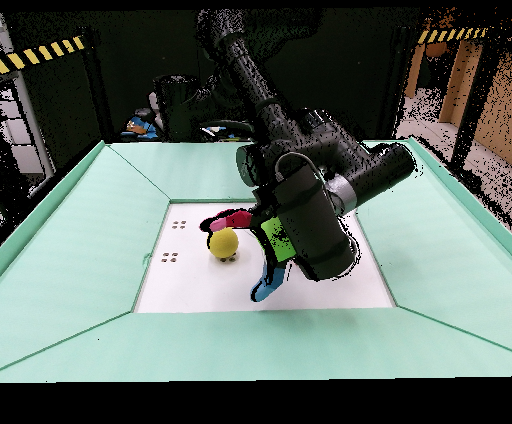

In [42]:
if not examples:
    raise RuntimeError("Brak przykladow do trenowania. Sprawdz sciezki obrazow i bboxy.")

examples[0]

In [43]:
from openai import OpenAI
import os

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Ustaw OPENAI_API_KEY przed uploadem i fine-tune.")

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [44]:
def save_jsonl(records: list[dict], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        for row in records:
            f.write(json.dumps(row, ensure_ascii=True) + "\n")

train_examples, val_examples = train_test_split(
    examples,
    test_size=0.1,
    random_state=42,
    shuffle=True,
    )

OUTPUT_DIR = Path("openai_finetune_bbox")
train_path = OUTPUT_DIR / "bbox_train.jsonl"
val_path = OUTPUT_DIR / "bbox_val.jsonl"

save_jsonl(train_examples, train_path)
save_jsonl(val_examples, val_path)

print(f"Train: {len(train_examples)} -> {train_path}")
print(f"Val: {len(val_examples)} -> {val_path}")

Train: 90 -> openai_finetune_bbox/bbox_train.jsonl
Val: 10 -> openai_finetune_bbox/bbox_val.jsonl


In [45]:
print("Przesylanie plikow JSONL do OpenAI...")

with open(train_path, "rb") as f:
    train_file = client.files.create(file=f, purpose="fine-tune")
print(f"train_file_id: {train_file.id}")

with open(val_path, "rb") as f:
    val_file = client.files.create(file=f, purpose="fine-tune")
print(f"val_file_id: {val_file.id}")

Przesylanie plikow JSONL do OpenAI...
train_file_id: file-AUJVeCTuL9UdzonxAjFCdR
val_file_id: file-P9b4yyiCLdeayHbFC8bXpy


In [49]:
BASE_MODEL = "gpt-4o-2024-08-06"

fine_tune_job = client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=val_file.id,
    model=BASE_MODEL,
    suffix="bbox-groundtruth",
)

print(f"Fine-tune job utworzony: {fine_tune_job.id}")
print(f"Status: {fine_tune_job.status}")
print(f"Model bazowy: {fine_tune_job.model}")

Fine-tune job utworzony: ftjob-2NMrHLgILwB6V9n3lvl0vj80
Status: validating_files
Model bazowy: gpt-4o-2024-08-06


In [50]:
job_info = client.fine_tuning.jobs.retrieve(fine_tune_job.id)
print(f"Job ID: {job_info.id}")
print(f"Status: {job_info.status}")
print(f"Fine-tuned model: {job_info.fine_tuned_model}")

Job ID: ftjob-2NMrHLgILwB6V9n3lvl0vj80
Status: queued
Fine-tuned model: None


## Inferencja dla Wytrenowanego modelu (Fine-Tuned) - 20 obrazów testowych

In [8]:
import re
from pathlib import Path
import numpy as np

# Zbiór testowy - 100 obrazów (indeksy od 20 do 119)
TEST_START = 20
TEST_END = 119 
test_paths = df.loc[TEST_START:TEST_END, "color_path"].reset_index(drop=True)
test_gt = gt_all[TEST_START:TEST_END + 1, :]

# Podmien nazwe na faktycznie nadana przez API po zakonczeniu Joba
FINETUNED_MODEL_NAME = "ft:gpt-4o-2024-08-06:iair:bbox-groundtruth:DJdr2H8w"
checkpoint_ft_path = Path(SAVE_DIR) / "LLM" / "xy_array_gpt_ft.npy"
checkpoint_ft_path.parent.mkdir(parents=True, exist_ok=True)

if checkpoint_ft_path.exists():
    loaded_ft = np.load(checkpoint_ft_path, allow_pickle=True)
    xy_array_gpt_ft = loaded_ft.tolist() if isinstance(loaded_ft, np.ndarray) else list(loaded_ft)
    start_ft_idx = len(xy_array_gpt_ft)
    print(f"Zrestartowano. Pobrano dotychczas {start_ft_idx} z {len(test_paths)} wynikow z pliku \'{checkpoint_ft_path.name}\'")
else:
    xy_array_gpt_ft = []
    start_ft_idx = 0
    print("Brak pliku wynikowego. Rozpoczynam od zera...")

for i in range(start_ft_idx, len(test_paths)):
    img_path = Path(test_paths[i])
    if not img_path.is_absolute():
        img_path = Path.cwd() / img_path
        
    test_data_url = image_to_data_url(img_path)
    
    print(f"Pytam model FT dla obrazu: {i+1}/{len(test_paths)}...")
    try:
        response = client.chat.completions.create(
            model=FINETUNED_MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": USER_PROMPT},
                        {"type": "image_url", "image_url": {"url": test_data_url, "detail": "high"}}
                    ],
                }
            ],
            max_tokens=150,
            temperature=0.0
        )
        output_text = response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Błąd API: {e}")
        output_text = ""
        
    xy_array_gpt_ft.append(output_text)
    
    # Checkpoint co 5 zapytan
    if (i+1) % 5 == 0:
        np.save(checkpoint_ft_path, np.array(xy_array_gpt_ft, dtype=object))

# Finalny zapis po pętli
# np.save(checkpoint_ft_path, np.array(xy_array_gpt_ft, dtype=object))
# print("Wszystko pobrane i zapisane poprawnie do numpy array!")

NameError: name 'gt_all' is not defined

## Formatowanie boxów i rzutowanie na Numpy Array

In [6]:
import re

def parse_bbox_rows_ft(arr):
    out = []
    for row in arr:
        text = str(row)
        # Zmieniamy regex na bardziej łagodny - po prostu wyciągamy wszystkie liczby zmiennoprzecinkowe,
        # co rozwiązuje problem, gdy model czasem pominie nawiasy (np. wypluje "0.12,0.34..." zamiast "(0.12,0.34...)")
        nums_str = re.findall(r'[0-9]*\.?[0-9]+', text)
        nums = [float(x) for x in nums_str]
        
        # dociecie/padding do 12 liczb (3 boxy po 4 współrzędne), gdyby gpt się pomylił z liczbą wyników
        if len(nums) < 12:
            nums += [0.0] * (12 - len(nums))
        else:
            nums = nums[:12]
        out.append(nums)
    return np.array(out, dtype=float)

xy_array_gpt_ft = np.load(f"{SAVE_DIR}/LLM/xy_array_gpt_ft.npy", allow_pickle=True).tolist()

xy_array_gpt_ft_bbox = parse_bbox_rows_ft(xy_array_gpt_ft)
print("Sformatowane predykcje Fine-Tuned (wiersze x wspolrzedne):", xy_array_gpt_ft_bbox.shape)

Sformatowane predykcje Fine-Tuned (wiersze x wspolrzedne): (100, 12)


### Wizualizacja predykcji samego modelu (bez Ground Truth)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Wizualizacja samego modelu Fine-Tuned (podgląd ogólny)
# Pętla na np pierwsze 2 obrazy testowe, żeby nie zaśmiecać całego notatnika
for id in range(0, 4):
    img_path = str(test_paths.iloc[id])
    if not Path(img_path).is_absolute():
        img_path = str(Path.cwd() / img_path)
        
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Model OpenAI FT zwraca 3 boxy z założenia: pink, green, blue
    boxes = xy_array_gpt_ft_bbox[id]
    colors = ["red", "green", "blue"]
    labels_text = ['Czerwony', 'Zielony', 'Niebieski']

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_rgb, alpha=0.35)

    for j in range(3):
        x_min, y_min, x_max, y_max = boxes[j * 4:(j + 1) * 4]
        rect = patches.Rectangle(
            (x_min * w, y_min * h), 
            (x_max - x_min) * w, 
            (y_max - y_min) * h,
            linewidth=2, 
            edgecolor=colors[j], 
            facecolor='none', 
            label=f"{labels_text[j]} element"
        )
        ax.add_patch(rect)

    plt.title(f"Obraz o ID: {id} - Otaczające prostokąty model Fine-Tuned")


    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### Porównanie: Model Fine-Tuned vs Ground Truth

In [ ]:
# Porównanie predykcji Fine-Tuned ze zbiorem referencyjnym (Ground Truth)
# Zakładamy, że tablica z ground truth zdefiniowana wyżej to `gt_all`
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Odtwarzamy test_gt bazując na wczytanej globalnie tablicy referncyjnej `gt_all`
test_gt = gt_all[TEST_START:TEST_END+1, :]

for id in range(min(5, len(test_paths))):  # Pokazujemy 5 pierwszych do sprawdzenia
    img_path = str(test_paths.iloc[id])
    if not Path(img_path).is_absolute():
        img_path = str(Path.cwd() / img_path)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Pobranie boxów modelu
    ft_boxes = xy_array_gpt_ft_bbox[id]

    # Pobranie boxów referencyjnych dla tego samego indeksu
    gt_boxes = test_gt[id]
    
    colors_ft = ["red", "green", "blue"]
    colors_gt = ["red", "green", "blue"]
    labels_text = ['Czerwony', 'Zielony', 'Niebieski']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Wykres 1: Modele FT ---
    axes[0].imshow(img_rgb, alpha=0.5)
    axes[0].set_title(f"Obraz o ID: {TEST_START+id} - Otaczające prostokąty Fine-Tuned (GPT-4o)")
    for j in range(3):
        x_min, y_min, x_max, y_max = ft_boxes[j * 4:(j + 1) * 4]
        if x_max > x_min and y_max > y_min:
            rect = patches.Rectangle(
                (x_min * w, y_min * h), 
                (x_max - x_min) * w, 
                (y_max - y_min) * h,
                linewidth=2.5, edgecolor=colors_ft[j], facecolor='none', 
                label=f"{labels_text[j]} element FT"
            )
            axes[0].add_patch(rect)
            
    # Upewniamy się, że legenda jest dodawana tylko wtedy, gdy są jakieś boxy
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend()
    axes[0].axis('off')

    # --- Wykres 2: Ground Truth ---
    axes[1].imshow(img_rgb, alpha=0.5)
    axes[1].set_title(f"Obraz o ID: {TEST_START+id} - Otaczające prostokąty Ground Truth")
    for j in range(3):
        x_min, y_min, x_max, y_max = gt_boxes[j * 4:(j + 1) * 4]
        if x_max > x_min and y_max > y_min:
            rect = patches.Rectangle(
                (x_min * w, y_min * h), 
                (x_max - x_min) * w, 
                (y_max - y_min) * h,
                linewidth=2.5, edgecolor=colors_gt[j], facecolor='none', 
                label=f"{labels_text[j]} element GT"
            )
            axes[1].add_patch(rect)
            
    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        axes[1].legend()
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()